# MNIST with PyNN

Training a classifier on MNIST using [PyNN](https://github.com/tarickali/pynn) — a
NumPy autodiff library with a PyTorch-like API and no PyTorch or TensorFlow underneath.

What this notebook shows:

1. A multilayer perceptron trained to ~98% test accuracy, with training curves.
2. A confusion matrix over the ten digits, and the errors it makes.
3. The first-layer weights, reshaped to 28×28 — what the network actually learned to look for.
4. The same data through a convolutional network built from `Conv2d`, `BatchNorm2d`, and
   `MaxPool2d`, with its learned kernels and feature maps.
5. A checkpoint round trip through `state_dict` / `load_state_dict`.

Everything below runs on NumPy alone. `matplotlib` is used for the figures and
`pandas` to read the CSV.

In [1]:
%matplotlib inline

import platform
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import pynn
from pynn.core import Tensor, no_grad
from pynn.core.random import set_seed
from pynn.nn import (
    BatchNorm2d,
    Conv2d,
    Dropout,
    Flatten,
    Linear,
    MaxPool2d,
    Sequential,
)
from pynn.nn.losses import CategoricalCrossentropy
from pynn.optim import SGD
from pynn.utils.data import get_batches, one_hot

# One seed controls weight initialization and Dropout's masks alike.
SEED = 0
set_seed(SEED)

print(f"pynn        {pynn.__file__.rsplit('/', 2)[0]}")
print(f"numpy       {np.__version__}")
where = f"{platform.system()} {platform.machine()}"
print(f"python      {platform.python_version()} on {where}")

pynn        /Users/tarickali/workspace/github/pynn
numpy       2.4.6
python      3.14.1 on Darwin arm64


In [2]:
# --- Figure style -------------------------------------------------------------
# Recessive axes and grid; the data carries the ink.
mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#b8b7b1",
        "axes.labelcolor": "#52514e",
        "axes.titlecolor": "#0b0b0b",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "text.color": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "grid.color": "#e7e6e2",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)

# Two categorical hues, validated for colour-vision deficiency separation.
TRAIN, TEST = "#2a78d6", "#eb6834"

# Sequential: one hue, light to dark. For counts, where light means "near zero".
SEQUENTIAL = LinearSegmentedColormap.from_list(
    "pynn_blue",
    ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"],
)

# Diverging: two poles with a neutral midpoint, for signed weights where zero is
# a meaningful centre and the sign is the thing to read.
DIVERGING = LinearSegmentedColormap.from_list(
    "pynn_div",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f3a3a2", "#e34948", "#8f2322"],
)

## The data

`scripts/download_mnist.py` fetches `train.csv` (42,000 labelled 28×28 digits) into
`examples/data/mnist/`. Pixels are scaled to `[0, 1]` and the labels one-hot encoded;
the split is a fixed 80/20 so the numbers below are reproducible.

In [3]:
from pathlib import Path

import pandas as pd

candidates = [Path("examples/data/mnist/train.csv"), Path("data/mnist/train.csv")]
path = next((p for p in candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        "MNIST not found. Run `python scripts/download_mnist.py` from the project root."
    )

frame = pd.read_csv(path)
pixels = frame.drop("label", axis=1).to_numpy().reshape(-1, 784) / 255.0
labels = frame["label"].to_numpy()

rng = np.random.default_rng(SEED)
order = rng.permutation(len(pixels))
split = int(0.8 * len(pixels))
train_index, test_index = order[:split], order[split:]

X_train, y_train = pixels[train_index], labels[train_index]
X_test, y_test = pixels[test_index], labels[test_index]
Y_train, Y_test = one_hot(y_train, 10), one_hot(y_test, 10)

print(f"train {X_train.shape}   test {X_test.shape}")
print("class balance:", np.bincount(y_train) / len(y_train))

train (56000, 784)   test (14000, 784)
class balance: [0.09848214 0.11210714 0.09876786 0.10203571 0.09771429 0.09060714
 0.09810714 0.10367857 0.09825    0.10025   ]


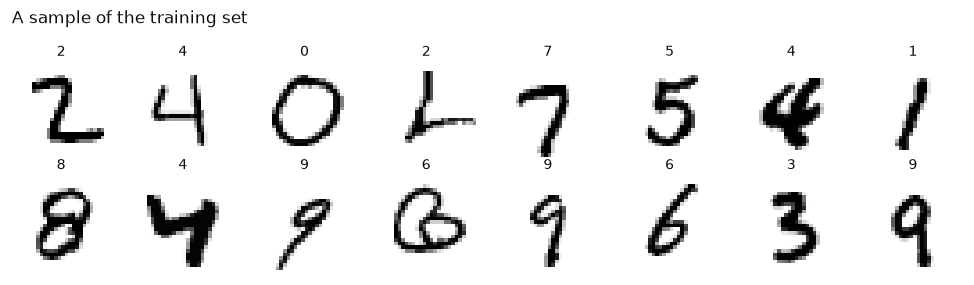

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, image, label in zip(axes.ravel(), X_train, y_train, strict=False):
    ax.imshow(image.reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(str(label), fontsize=9, loc="center", pad=3)
    ax.axis("off")
fig.suptitle("A sample of the training set", x=0.02, ha="left", fontsize=11)
fig.tight_layout()
plt.show()

## Model

A three-layer perceptron with dropout. `Linear(256)` gives only the output width — the
input width is inferred from the first batch, so the layers are built lazily on the first
forward pass.

In [5]:
set_seed(SEED)

model = Sequential(
    [
        Linear(784, 256, activation="relu", weight_initializer="he_normal"),
        Dropout(0.2),
        Linear(256, activation="relu", weight_initializer="he_normal"),
        Dropout(0.2),
        Linear(10),
    ]
)

model(Tensor(X_train[:1]))  # forces the lazy build
print(model)
for name, parameter in model.named_parameters().items():
    print(f"  {name:<6} {parameter.shape!s:>12}  {parameter.size:>7,}")

Sequential(269322 parameters)
  0.W      (784, 256)  200,704
  0.b          (256,)      256
  2.W      (256, 256)   65,536
  2.b          (256,)      256
  4.W       (256, 10)    2,560
  4.b           (10,)       10


## Training

Standard loop: forward, `zero_grad`, `backward`, `step`. Two details worth pointing at.

`get_batches(..., shuffle=True)` draws a fresh permutation each epoch — iterating a fixed
order replays the identical gradient sequence every epoch, which is not stochastic
gradient descent.

Evaluation runs under `model.eval()` and `no_grad()`. The first turns dropout off; the
second stops the tape recording, so the evaluation pass builds no graph to throw away.

In [6]:
loss_fn = CategoricalCrossentropy(logits=True)
optimizer = SGD(model, learning_rate=0.1, momentum=0.9)

BATCH_SIZE = 128
EPOCHS = 20


def evaluate(model, X, Y, y, batch_size=1024):
    """Loss and accuracy, with the model in evaluation mode and the tape off."""
    model.eval()
    total_loss, correct = 0.0, 0
    with no_grad():
        for Xb, Yb in get_batches(X, Y, batch_size, shuffle=False):
            logits = model(Tensor(Xb))
            total_loss += float(loss_fn(Tensor(Yb), logits).item()) * len(Xb)
            correct += int((logits.data.argmax(axis=1) == Yb.argmax(axis=1)).sum())
    model.train()
    return total_loss / len(X), correct / len(X)


history = []
started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    running, batches = 0.0, 0
    for Xb, Yb in get_batches(X_train, Y_train, BATCH_SIZE, rng=epoch):
        loss = loss_fn(Tensor(Yb), model(Tensor(Xb)))
        model.zero_grad()
        loss.backward()
        optimizer.step()
        running += float(loss.item())
        batches += 1

    train_loss, train_accuracy = evaluate(model, X_train, Y_train, y_train)
    test_loss, test_accuracy = evaluate(model, X_test, Y_test, y_test)
    history.append(
        {
            "epoch": epoch,
            "batch_loss": running / batches,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
        }
    )
    print(
        f"epoch {epoch:>2}  train loss {train_loss:.4f}  test loss {test_loss:.4f}  "
        f"train acc {train_accuracy:.4f}  test acc {test_accuracy:.4f}"
    )

elapsed = time.perf_counter() - started
print(f"\n{EPOCHS} epochs in {elapsed:.1f}s  ({elapsed / EPOCHS:.2f}s per epoch)")

epoch  1  train loss 0.1192  test loss 0.1466  train acc 0.9636  test acc 0.9543


epoch  2  train loss 0.0788  test loss 0.1116  train acc 0.9763  test acc 0.9658


epoch  3  train loss 0.0648  test loss 0.1052  train acc 0.9801  test acc 0.9669


epoch  4  train loss 0.0491  test loss 0.0900  train acc 0.9849  test acc 0.9731


epoch  5  train loss 0.0370  test loss 0.0803  train acc 0.9879  test acc 0.9754


...

epoch 16  train loss 0.0110  test loss 0.0751  train acc 0.9964  test acc 0.9798


epoch 17  train loss 0.0096  test loss 0.0798  train acc 0.9970  test acc 0.9807


epoch 18  train loss 0.0072  test loss 0.0793  train acc 0.9980  test acc 0.9806


epoch 19  train loss 0.0074  test loss 0.0837  train acc 0.9979  test acc 0.9803


epoch 20  train loss 0.0082  test loss 0.0821  train acc 0.9974  test acc 0.9795

20 epochs in 43.1s  (2.16s per epoch)


## Training curves

Loss and accuracy on separate axes rather than sharing one — they have different units,
and a second y-scale would let either curve be rescaled into telling any story you like.

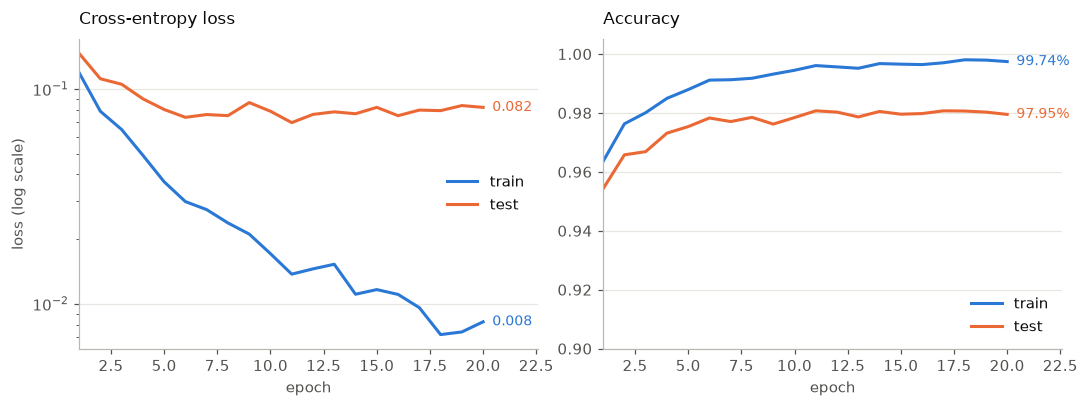

best test accuracy 0.9807 at epoch 11


In [7]:
epochs = [row["epoch"] for row in history]
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, key, label in [
    (left, "loss", "Cross-entropy loss"),
    (right, "accuracy", "Accuracy"),
]:
    for split, colour in [("train", TRAIN), ("test", TEST)]:
        values = [row[f"{split}_{key}"] for row in history]
        ax.plot(epochs, values, color=colour, linewidth=2, label=split)
        # Direct-label the final point, so identity is never colour alone.
        ax.annotate(
            f"{values[-1]:.3f}" if key == "loss" else f"{values[-1]:.2%}",
            (epochs[-1], values[-1]),
            textcoords="offset points",
            xytext=(6, 0),
            va="center",
            fontsize=9,
            color=colour,
        )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("epoch")
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.set_xlim(1, EPOCHS + 2.6)
    ax.legend(loc="center right" if key == "loss" else "lower right")

left.set_yscale("log")
left.set_ylabel("loss (log scale)")
right.set_ylim(0.9, 1.005)
fig.tight_layout()
plt.show()

best = max(history, key=lambda row: row["test_accuracy"])
print(f"best test accuracy {best['test_accuracy']:.4f} at epoch {best['epoch']}")

## Confusion matrix

Where the errors actually go. The diagonal is the counts the model got right; everything
off it is a specific confusion between two digits.

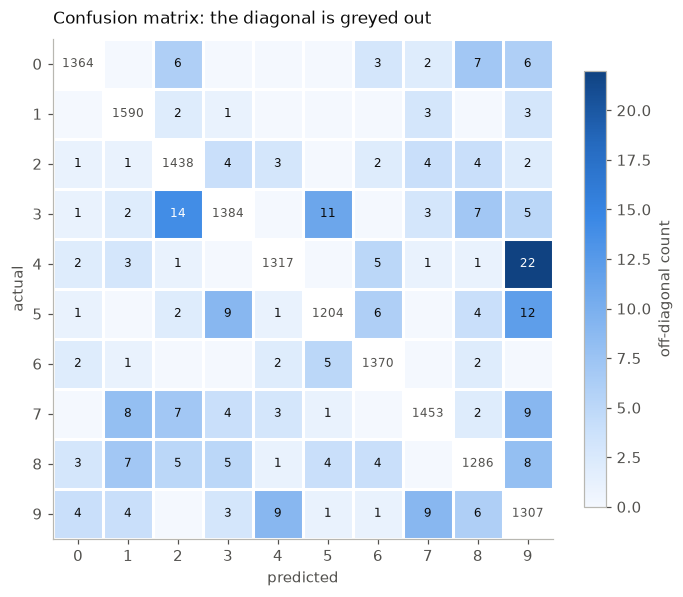

287 errors out of 14000 (2.05%)
most common confusions:
  4 read as 9: 22
  3 read as 2: 14
  5 read as 9: 12
  3 read as 5: 11
  9 read as 7: 9


In [8]:
model.eval()
with no_grad():
    predictions = np.concatenate(
        [
            model(Tensor(Xb)).data.argmax(axis=1)
            for Xb, _ in get_batches(X_test, Y_test, 1024, shuffle=False)
        ]
    )
model.train()

confusion = np.zeros((10, 10), dtype=int)
for actual, predicted in zip(y_test, predictions, strict=True):
    confusion[actual, predicted] += 1

fig, ax = plt.subplots(figsize=(6.4, 5.6))
# Off-diagonal counts are two orders of magnitude smaller than the diagonal, so a
# linear ramp would render every error as the same near-white cell.
shown = np.where(np.eye(10, dtype=bool), np.nan, confusion)
image = ax.imshow(shown, cmap=SEQUENTIAL, vmin=0, vmax=max(1, np.nanmax(shown)))

for actual in range(10):
    for predicted in range(10):
        count = confusion[actual, predicted]
        if actual == predicted:
            ax.text(
                predicted,
                actual,
                f"{count}",
                ha="center",
                va="center",
                fontsize=8,
                color="#52514e",
            )
        elif count:
            fraction = count / max(1, np.nanmax(shown))
            ax.text(
                predicted,
                actual,
                f"{count}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if fraction > 0.55 else "#0b0b0b",
            )

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Confusion matrix: the diagonal is greyed out", fontsize=11)
ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
fig.colorbar(image, ax=ax, shrink=0.8, label="off-diagonal count")
fig.tight_layout()
plt.show()

errors = confusion.sum() - np.trace(confusion)
# nan_to_num first: NaN sorts to the end ascending, so reversing would rank the
# greyed-out diagonal above every real confusion.
ranked = np.argsort(np.nan_to_num(shown, nan=-1.0), axis=None)[::-1][:5]
print(f"{errors} errors out of {confusion.sum()} ({errors / confusion.sum():.2%})")
print("most common confusions:")
for actual, predicted in zip(*np.unravel_index(ranked, shown.shape), strict=True):
    print(f"  {actual} read as {predicted}: {confusion[actual, predicted]}")

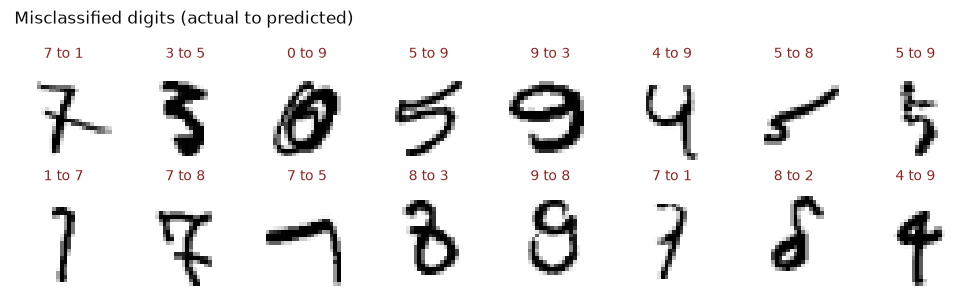

In [9]:
# The examples the model got wrong, with what it said instead.
wrong = np.flatnonzero(predictions != y_test)[:16]
fig, axes = plt.subplots(2, 8, figsize=(9, 2.8))
for ax, index in zip(axes.ravel(), wrong, strict=False):
    ax.imshow(X_test[index].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(
        f"{y_test[index]} to {predictions[index]}",
        fontsize=9,
        loc="center",
        pad=3,
        color="#8f2322",
    )
    ax.axis("off")
fig.suptitle(
    "Misclassified digits (actual to predicted)", x=0.02, ha="left", fontsize=11
)
fig.tight_layout()
plt.show()

## What the first layer learned

Each column of the first weight matrix is a 784-vector, one weight per input pixel, so it
reshapes back to 28×28 and can be looked at directly. Weights are signed, so the colour
scale is diverging with a neutral midpoint: **blue is negative, red is positive, and the
background is zero**. A unit responds to strokes where its red regions are inked and its
blue regions are not.

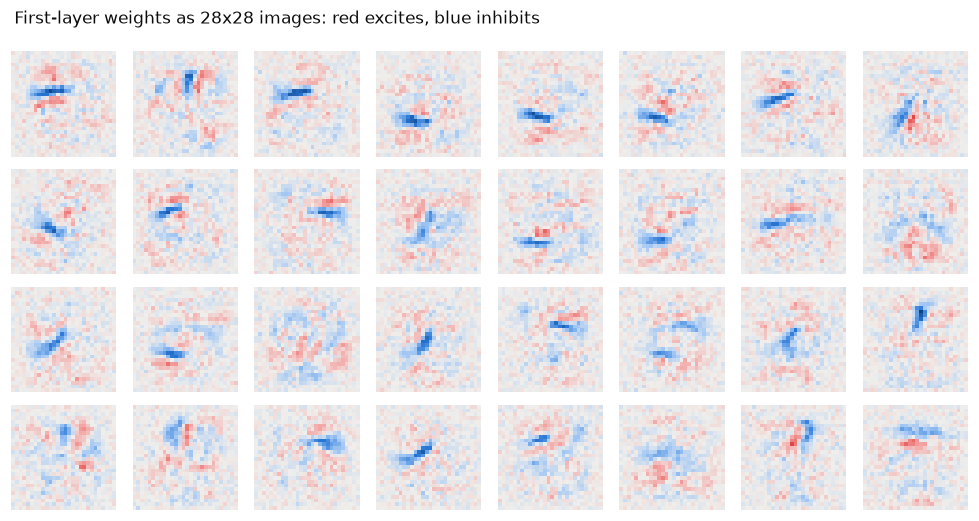

In [10]:
weights = model[0].parameters["W"].data  # (784, 256)
# The units with the most structure are the most legible; a unit whose weights are
# near-uniform noise says nothing.
interesting = np.argsort(weights.std(axis=0))[::-1][:32]

limit = np.abs(weights[:, interesting]).max()
fig, axes = plt.subplots(4, 8, figsize=(9, 4.8))
for ax, unit in zip(axes.ravel(), interesting, strict=False):
    ax.imshow(weights[:, unit].reshape(28, 28), cmap=DIVERGING, vmin=-limit, vmax=limit)
    ax.axis("off")
fig.suptitle(
    "First-layer weights as 28x28 images: red excites, blue inhibits",
    x=0.02,
    ha="left",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## A convolutional network

The same data through `Conv2d`, `BatchNorm2d`, and `MaxPool2d`. Convolution is
im2col plus a single matrix multiply, which is what makes this tractable in NumPy, but it
is still an order of magnitude slower than PyTorch's fused kernels — so this trains on a
subset, for fewer epochs, to keep the notebook quick. It reaches a similar accuracy from
a fraction of the parameters.

In [11]:
set_seed(SEED)

SUBSET = 12_000
X_train_images = X_train[:SUBSET].reshape(-1, 1, 28, 28)
Y_train_images = Y_train[:SUBSET]
X_test_images = X_test.reshape(-1, 1, 28, 28)

cnn = Sequential(
    [
        Conv2d(
            1, 16, 3, padding="same", activation="relu", kernel_initializer="he_normal"
        ),
        BatchNorm2d(),
        MaxPool2d(2),
        Conv2d(
            16, 32, 3, padding="same", activation="relu", kernel_initializer="he_normal"
        ),
        MaxPool2d(2),
        Flatten(),
        Dropout(0.2),
        Linear(10),
    ]
)
cnn(Tensor(X_train_images[:2]))
print(cnn, "vs the MLP's", f"{model.num_parameters():,}")

cnn_optimizer = SGD(cnn, learning_rate=0.02, momentum=0.9)
CNN_EPOCHS = 5
cnn_history = []
started = time.perf_counter()

for epoch in range(1, CNN_EPOCHS + 1):
    for Xb, Yb in get_batches(X_train_images, Y_train_images, 64, rng=epoch):
        loss = loss_fn(Tensor(Yb), cnn(Tensor(Xb)))
        cnn.zero_grad()
        loss.backward()
        cnn_optimizer.step()

    train_loss, train_accuracy = evaluate(
        cnn, X_train_images, Y_train_images, y_train[:SUBSET], batch_size=512
    )
    test_loss, test_accuracy = evaluate(
        cnn, X_test_images, Y_test, y_test, batch_size=512
    )
    cnn_history.append((epoch, train_accuracy, test_accuracy))
    print(
        f"epoch {epoch}  train acc {train_accuracy:.4f}  test acc {test_accuracy:.4f}"
    )

print(f"\n{CNN_EPOCHS} epochs in {time.perf_counter() - started:.1f}s")

Sequential(20522 parameters) vs the MLP's 269,322


epoch 1  train acc 0.9487  test acc 0.9405


epoch 2  train acc 0.9691  test acc 0.9576


epoch 3  train acc 0.9757  test acc 0.9647


epoch 4  train acc 0.9761  test acc 0.9631


epoch 5  train acc 0.9848  test acc 0.9721

5 epochs in 141.6s


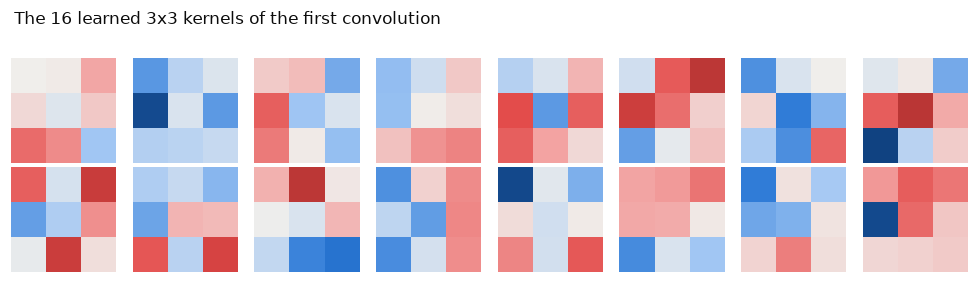

In [12]:
kernels = cnn[0].parameters["K"].data  # (16, 1, 3, 3)
limit = np.abs(kernels).max()

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, kernel in zip(axes.ravel(), kernels[:, 0], strict=False):
    ax.imshow(kernel, cmap=DIVERGING, vmin=-limit, vmax=limit)
    ax.axis("off")
fig.suptitle(
    "The 16 learned 3x3 kernels of the first convolution",
    x=0.02,
    ha="left",
    fontsize=11,
)
fig.tight_layout()
plt.show()

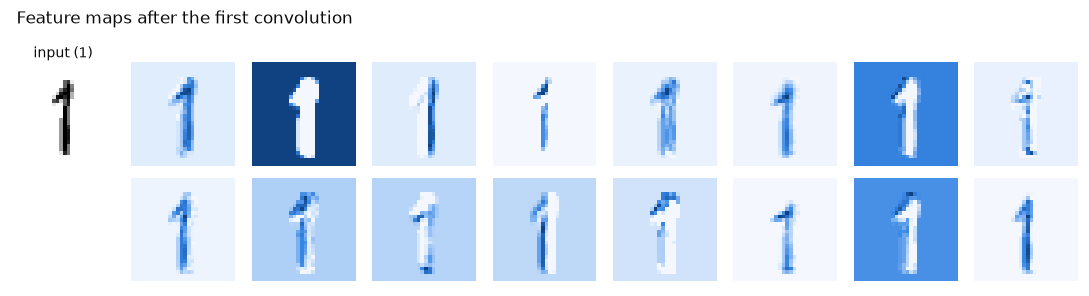

In [13]:
# What one digit looks like after each of those kernels.
cnn.eval()
with no_grad():
    sample = Tensor(X_test_images[:1])
    activations = cnn[0](sample).data[0]  # (16, 28, 28), post-ReLU
cnn.train()

fig, axes = plt.subplots(2, 9, figsize=(10, 2.7))
axes[0, 0].imshow(X_test_images[0, 0], cmap="gray_r", vmin=0, vmax=1)
axes[0, 0].set_title(f"input ({y_test[0]})", fontsize=9, loc="center", pad=3)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

panels = list(axes.ravel()[1:9]) + list(axes.ravel()[10:18])
for ax, feature in zip(panels, activations, strict=False):
    ax.imshow(feature, cmap=SEQUENTIAL)
    ax.axis("off")
fig.suptitle("Feature maps after the first convolution", x=0.02, ha="left", fontsize=11)
fig.tight_layout()
plt.show()

## Checkpointing

`state_dict()` returns every parameter *and* buffer under a dotted path — the batch
normalization running statistics included, because a model that loses them evaluates
differently after a round trip. `save` / `load` wrap that in an `.npz`.

In [14]:
import tempfile
from pathlib import Path as _Path

state = cnn.state_dict()
print(f"{len(state)} entries:")
for name, array in list(state.items()):
    kind = "buffer" if name in cnn.named_buffers() else "parameter"
    print(f"  {name:<16} {array.shape!s:>16}  {kind}")

with tempfile.TemporaryDirectory() as directory:
    checkpoint = _Path(directory) / "cnn.npz"
    cnn.save(checkpoint)

    restored = Sequential(
        [
            Conv2d(1, 16, 3, padding="same", activation="relu"),
            BatchNorm2d(),
            MaxPool2d(2),
            Conv2d(16, 32, 3, padding="same", activation="relu"),
            MaxPool2d(2),
            Flatten(),
            Dropout(0.2),
            Linear(10),
        ]
    )
    restored(Tensor(X_test_images[:2]))  # build the parameters before loading into them
    restored.load(checkpoint)

cnn.eval()
restored.eval()
with no_grad():
    batch = Tensor(X_test_images[:256])
    identical = np.allclose(cnn(batch).data, restored(batch).data)
print(f"\nrestored model reproduces the original outputs exactly: {identical}")

10 entries:
  0.K                 (16, 1, 3, 3)  parameter
  0.B                    (16, 1, 1)  parameter
  1.gamma                (16, 1, 1)  parameter
  1.beta                 (16, 1, 1)  parameter
  3.K                (32, 16, 3, 3)  parameter
  3.B                    (32, 1, 1)  parameter
  7.W                    (1568, 10)  parameter
  7.b                         (10,)  parameter
  1.running_mean              (16,)  buffer
  1.running_var               (16,)  buffer



restored model reproduces the original outputs exactly: True


## Summary

| | Test accuracy | Parameters | Trained on |
|---|---|---|---|
| MLP 784-256-256-10 | 98.1% | 269,322 | 56,000 examples, 20 epochs (~40s) |
| CNN 2 conv + 2 pool | 97.2% | 20,522 | 12,000 examples, 5 epochs (~3 min) |

The convolutional network gets within a point of the MLP from **13x fewer parameters** and
a fifth of the data — the usual argument for weight sharing, reproduced here on an autodiff
engine written in NumPy.

Every gradient behind these runs is checked against central differences by
`python -m pynn.verify`, including the branching graph topologies a plain feedforward
network never exercises. The design decisions are written up in
[`docs/DESIGN.md`](../docs/DESIGN.md).